# First Vertical Derivative (FVD) technique
## Step1: Create synthetic data using `SimPEG`


In [67]:
import numpy as np
import matplotlib.pyplot as plt

from discretize import TensorMesh
from simpeg import maps
from simpeg.potential_fields import magnetics

# ----------------------------
# 1) Create a 3D mesh
# ----------------------------
# Horizontal cell size ~ 20 m, vertical ~ 10 m (adjust as desired)
dx = 100.0
dy = 100.0
dz = 50.0

# Domain (m): ~6 km x 6 km x 1 km
nx, ny, nz = 60, 60, 20

hx = dx * np.ones(nx)
hy = dy * np.ones(ny)
hz = dz * np.ones(nz)

mesh = TensorMesh([hx, hy, hz], x0="CCN")  # centered in x,y; z positive down
# Convenience arrays
cc = mesh.cell_centers
Xc, Yc, Zc = cc[:, 0], cc[:, 1], cc[:, 2]  # Z positive down
from simpeg.utils import model_builder
p0 = np.array([-1000, -1000, -500])
p1 = np.array([+1000, +1000, -700])
blk_inds = model_builder.get_indices_block(p0, p1, cc)
chi = np.zeros(mesh.n_cells)
chi[blk_inds] = 0.01

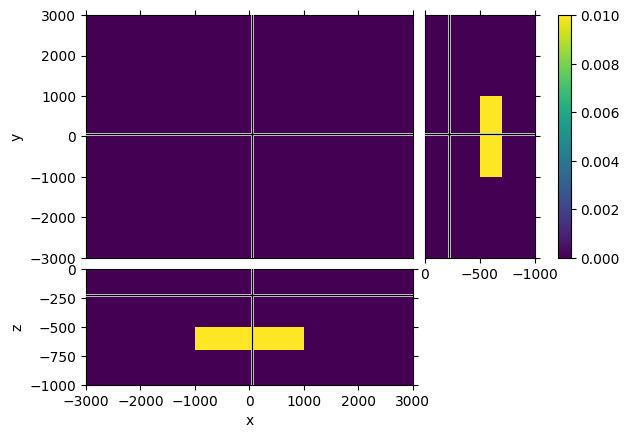

In [68]:
mesh.plot_3d_slicer(chi, zslice=-200)

In [69]:
# ----------------------------
# 3) Define observation grid at surface
# ----------------------------
# Observation elevation: z = 0 (top of mesh is at z ~ 0 because x0="CCN")
# We'll sample a grid over the central area.
x = np.linspace(-4000, 4000, 201)
y = np.linspace(-4000, 4000, 201)
X, Y = np.meshgrid(x, y, indexing="xy")
Z = np.zeros_like(X) + 1e-3  # surface

rx_locs = np.c_[X.ravel(), Y.ravel(), Z.ravel()]

# Define the inducing field
inclination = 90  # inclination [deg]
declination = 0  # declination [deg]
amplitude = 56188.7  # amplitude [nT]

components = ["tmi"]

receiver_list = magnetics.receivers.Point(rx_locs, components=components)
receiver_list = [receiver_list]

source_field = magnetics.sources.UniformBackgroundField(
    receiver_list=receiver_list,
    amplitude=amplitude,
    inclination=inclination,
    declination=declination,
)

# Define the survey
survey = magnetics.survey.Survey(source_field)

# ----------------------------
# 4) Forward model TMI
# ----------------------------
# Integral simulation (fast for mag); uses susceptibility directly

simulation = magnetics.simulation.Simulation3DIntegral(
    survey=survey,
    mesh=mesh,
    model_type="scalar",
    chiMap=maps.IdentityMap(nP=mesh.n_cells),
    # active_cells=active_cells,
    store_sensitivities="forward_only",
    engine="choclo",
)

tmi = simulation.dpred(chi)  # nT (TMI anomaly)

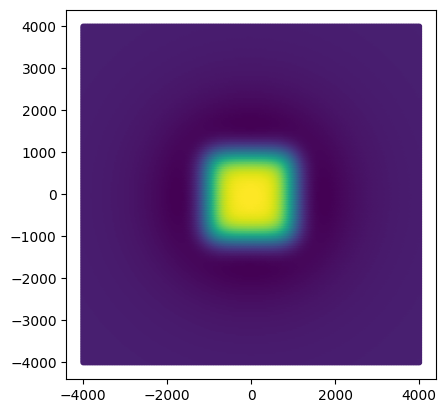

In [70]:
plt.scatter(rx_locs[:,0], rx_locs[:,1], c=tmi, s=10)
plt.gca().set_aspect(1)
# plt.scatter(rx_locs[inds_nan,0], rx_locs[inds_nan,1],  s=10)

## Step2: Implement FVD

In [99]:
# Add noise (optional)
noise_std = 0  # nT
tmi_noisy = tmi + noise_std * np.random.randn(tmi.size)

# Reshape to grid
B = tmi_noisy.reshape(Y.shape)  # ny x nx (since y varies outer)

In [100]:
def plane_remove(X, Y, B):
    """
    Remove best-fit plane a + b x + c y from grid B(X,Y).
    X, Y are 2D meshgrid arrays in meters.
    """
    G = np.c_[np.ones(X.size), X.ravel(), Y.ravel()]
    m, *_ = np.linalg.lstsq(G, B.ravel(), rcond=None)
    plane = (G @ m).reshape(B.shape)
    return B - plane, plane

def fvd_fft_2d(B, dx, dy, z_up=20.0, pad_frac=0.5, taper_frac=0.15):
    """
    FVD via FFT with edge-mitigation:
      - reflect padding
      - cosine taper window (on padded grid)
      - optional upward continuation stabilization
      - crop back to original size

    B: (ny, nx) grid
    dx, dy: grid spacings (m)
    z_up: stabilization height (m)
    pad_frac: padding as fraction of original size (e.g., 0.5 means +50% each side)
    taper_frac: taper width as fraction of padded dimension (0.1-0.2 typical)
    """
    ny, nx = B.shape

    # Padding sizes
    px = int(np.ceil(pad_frac * nx))
    py = int(np.ceil(pad_frac * ny))

    # Reflect pad to reduce discontinuities at boundaries
    B_padded = np.pad(B, ((py, py), (px, px)), mode="reflect")

    ny2, nx2 = B_padded.shape
    # FFT
    F = np.fft.fft2(B_padded)

    # Wavenumbers
    fx = np.fft.fftfreq(nx2, d=dx)
    fy = np.fft.fftfreq(ny2, d=dy)
    kx = 2*np.pi*fx
    ky = 2*np.pi*fy
    KX, KY = np.meshgrid(kx, ky, indexing="xy")
    K = np.sqrt(KX**2 + KY**2)

    # Stabilization (upward continuation)
    stab = np.exp(-K * z_up) if z_up and z_up > 0 else 1.0

    # FVD operator (sign convention ignored; magnitude enhancement)
    F_fvd = (K * stab) * F
    fvd_padded = np.real(np.fft.ifft2(F_fvd))

    # Crop to original size
    fvd = fvd_padded[py:py+ny, px:px+nx]
    return fvd

# --- Use the functions here ---

# 1) plane removal helps a lot for edge artifacts
B_detrended, plane = plane_remove(X, Y, B)

# 2) compute FVD with padding + taper + crop
z_up = 0          # increase if noisy / still ringing
fvd = fvd_fft_2d(B_detrended, dx_obs, dy_obs, z_up=z_up, pad_frac=1, taper_frac=0.1)

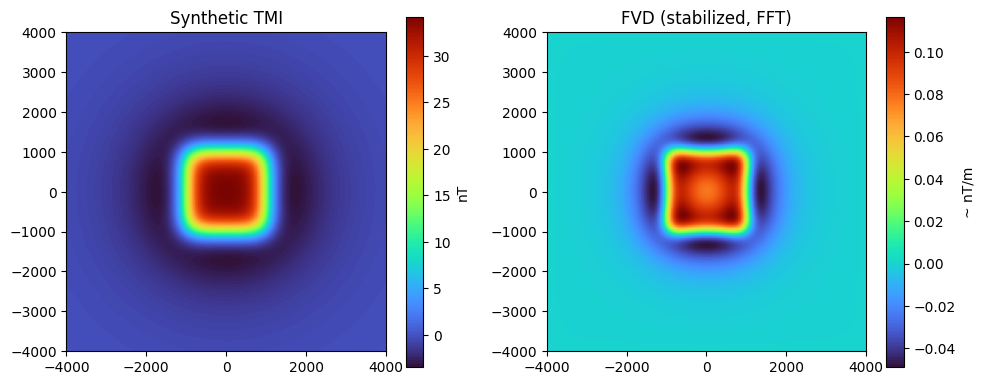

In [101]:
# ----------------------------
# 6) Plot
# ----------------------------
extent = [x.min(), x.max(), y.min(), y.max()]

plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.imshow(B, origin="lower", extent=extent, cmap='turbo')
plt.colorbar(label="nT")
plt.title("Synthetic TMI")

plt.subplot(1,2,2)
plt.imshow(fvd, origin="lower", extent=extent, cmap='turbo')
plt.colorbar(label="~ nT/m")  # approximate; depends on conventions + stabilization
plt.title("FVD (stabilized, FFT)")

plt.tight_layout()
plt.show()

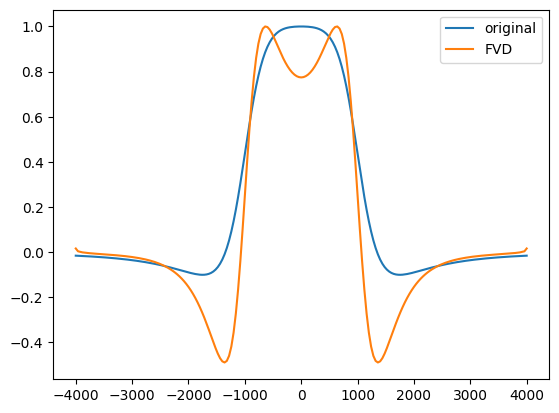

In [106]:
plt.plot(x, B[:,100]/B[:,100].max(), label='original')
plt.plot(x, fvd[:,100]/fvd[:,100].max(), label='FVD')
plt.legend()